In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [151]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset(1).csv')

In [152]:
df.shape

(4000, 28)

In [153]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [154]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [155]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [156]:
df.duplicated().sum()

np.int64(0)

In [157]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())

df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())

df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

In [158]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


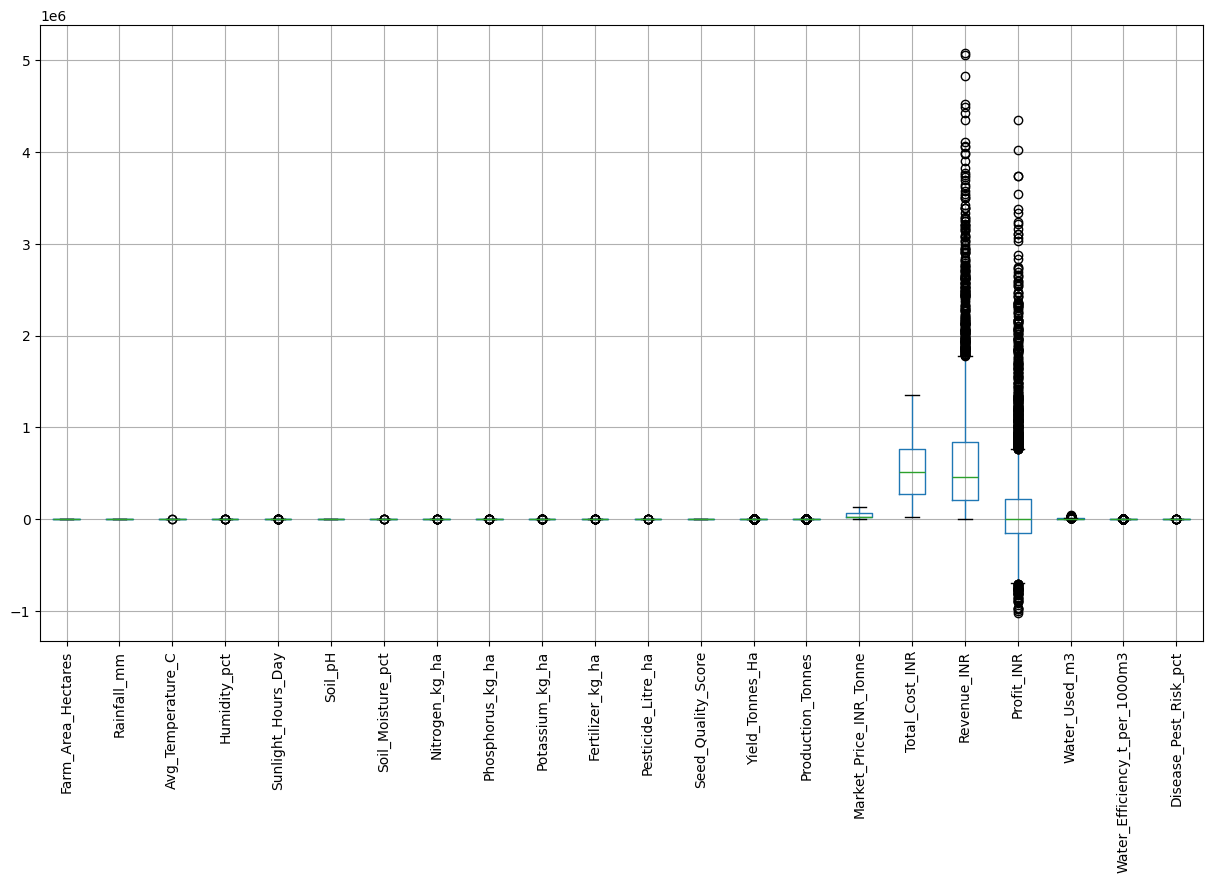

In [159]:
df.select_dtypes(include=np.number).boxplot(figsize=(15, 8))
plt.xticks(rotation=90)
plt.show()

In [160]:
print("States:", df['State'].nunique())
print("Crops:", df['Crop'].nunique())
print("Seasons:", df['Season'].nunique())
print("Irrigation Methods:", df['Irrigation_Method'].nunique())

States: 8
Crops: 8
Seasons: 3
Irrigation Methods: 4


In [161]:
df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [162]:
season_performance = df.groupby('Season')[[
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Revenue_INR',
    'Profit_INR'
]].mean()

season_performance

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Season,,,,
Kharif,5.628612,46.311192,710719.055649,178914.647555
Rabi,5.039435,41.486712,601526.048556,87689.470191
Zaid,4.641313,38.886111,519171.904040,-24804.824916


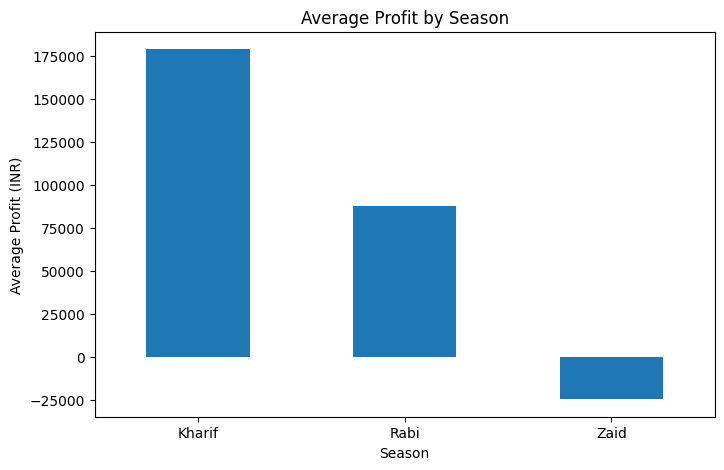

In [163]:
season_performance['Profit_INR'].plot(kind='bar', figsize=(8,5))

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=0)
plt.show()

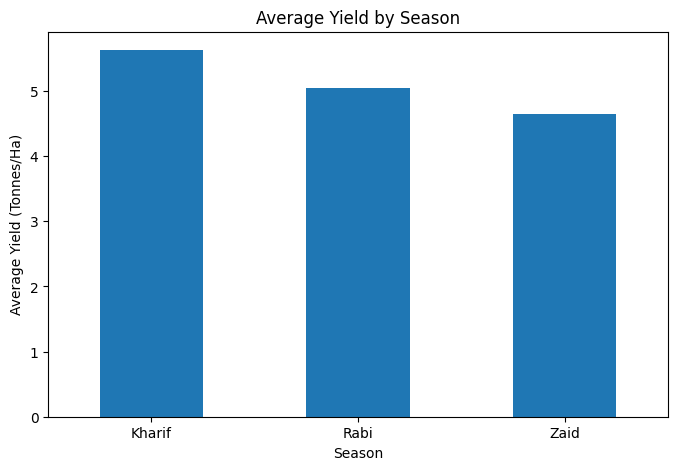

In [164]:
season_performance['Yield_Tonnes_Ha'].plot(kind='bar', figsize=(8,5))

plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.show()

In [165]:
crop_season_yield = df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].mean().unstack()

crop_season_yield

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,1.731459,1.374512,1.484974,2.966410,1.036063,2.698376,53.459120,2.253664
Rabi,1.465031,1.198358,1.233164,2.603648,0.875962,2.322847,43.286124,2.057468
Zaid,1.195312,0.960217,1.037778,2.290952,0.669677,1.900490,38.423922,1.748588


Insight:
Crop-wise analysis shows that Sugarcane has the highest average yield across all seasons. For most crops, average yield is highest in Kharif and decreases in Rabi and Zaid. Pulses show the lowest average yield among the crops in this dataset.

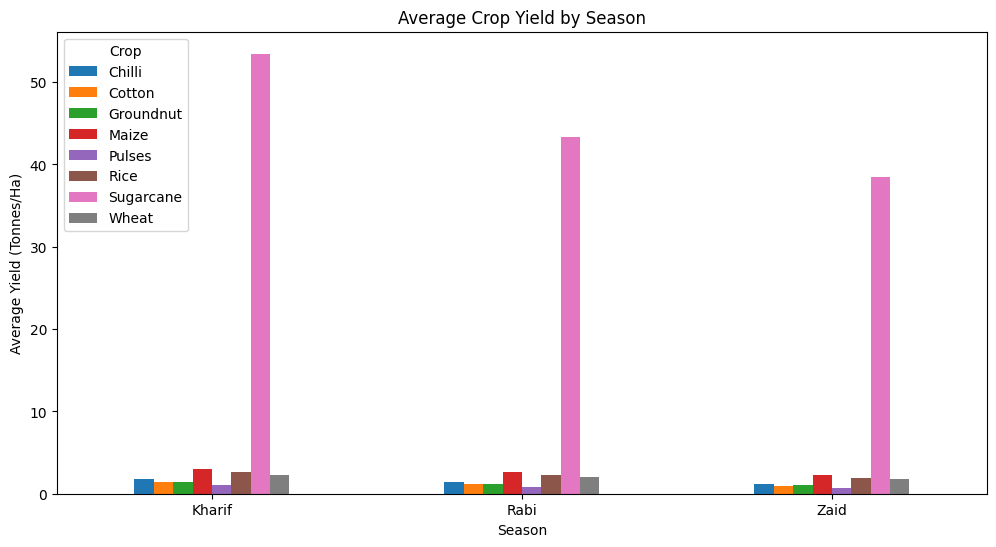

In [166]:
crop_season_yield.plot(kind='bar', figsize=(12,6))

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.legend(title='Crop')
plt.show()

Insight:Sugarcane has the highest average yield across all three seasons. Most crops show the highest yield in Kharif and lower yield in Rabi and Zaid. Pulses have the lowest average yield in this dataset.

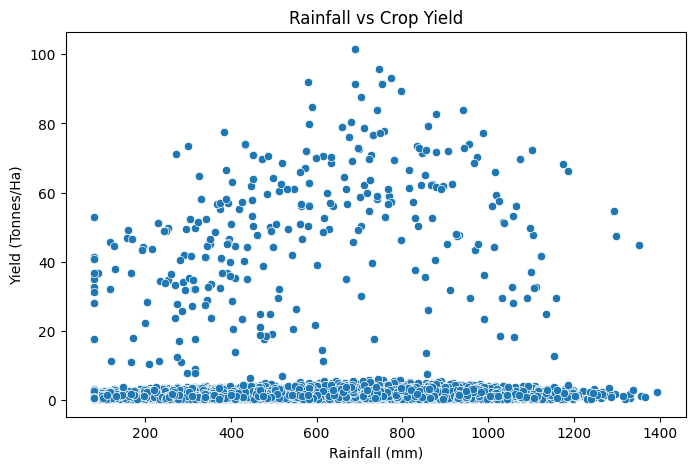

In [167]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha'
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

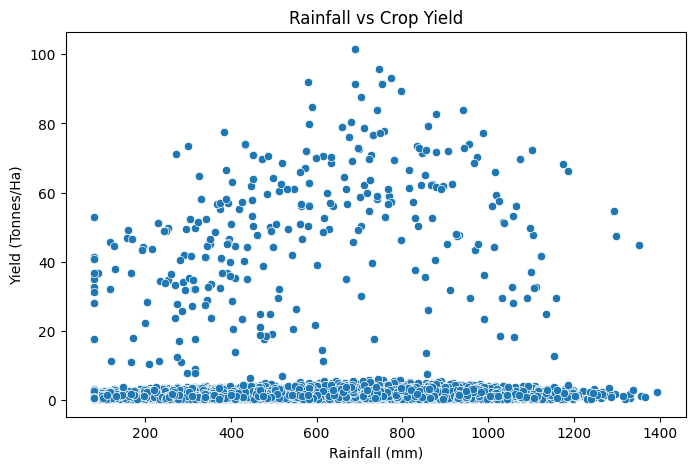

In [168]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha'
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [169]:
rainfall_yield_corr = df['Rainfall_mm'].corr(df['Yield_Tonnes_Ha'])

print("Correlation between Rainfall and Yield:", rainfall_yield_corr)

Correlation between Rainfall and Yield: 0.030950993551650874


Insight: The correlation between rainfall and crop yield is approximately 0.031, indicating a very weak positive linear relationship. Therefore, rainfall alone does not show a strong linear relationship with crop yield in this dataset.

In [170]:
temperature_yield_corr = df['Avg_Temperature_C'].corr(df['Yield_Tonnes_Ha'])

print("Correlation between Temperature and Yield:", temperature_yield_corr)

Correlation between Temperature and Yield: 0.009996320546703593


Insight: The correlation between average temperature and crop yield is approximately 0.010, indicating a very weak positive linear relationship. Therefore, temperature alone does not show a strong linear relationship with crop yield in this dataset.

In [171]:
soil_moisture_yield_corr = df['Soil_Moisture_pct'].corr(df['Yield_Tonnes_Ha'])

print("Correlation between Soil Moisture and Yield:", soil_moisture_yield_corr)

Correlation between Soil Moisture and Yield: 0.010999346063015853



Insight :The correlation between soil moisture and crop yield is approximately 0.011, indicating a very weak positive linear relationship. This suggests that soil moisture alone does not show a strong linear relationship with yield in this dataset. Other factors may also influence crop yield.

In [172]:
humidity_yield_corr = df['Humidity_pct'].corr(df['Yield_Tonnes_Ha'])
print("Correlation between Humidity and Yield:", humidity_yield_corr)

Correlation between Humidity and Yield: 0.012297441843645498


Insight:The correlation between humidity and crop yield is approximately 0.012, indicating a very weak positive linear relationship. This suggests that humidity alone does not show a strong linear relationship with yield in this dataset. Other factors may also influence crop yield.

In [173]:
soil_ph_yield_corr = df['Soil_pH'].corr(df['Yield_Tonnes_Ha'])
print("Correlation between Soil pH and Yield:", soil_ph_yield_corr)


Correlation between Soil pH and Yield: -0.020671587889240724


In [174]:
irrigation_yield = df.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].mean()
print(irrigation_yield)


Irrigation_Method
Drip         6.577989
Flood        4.863977
Rainfed      4.602142
Sprinkler    5.160627
Name: Yield_Tonnes_Ha, dtype: float64


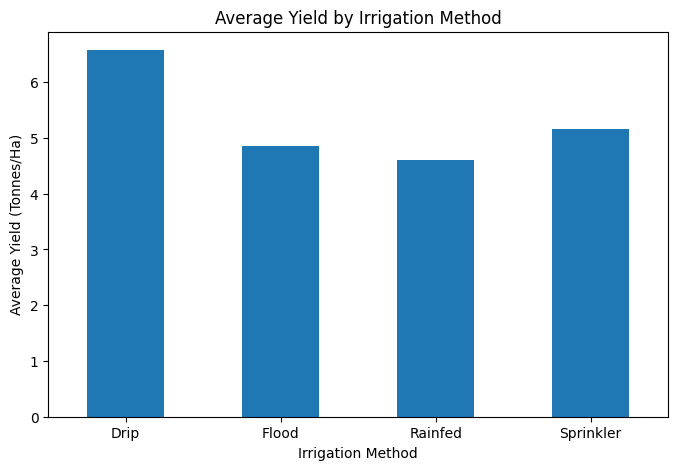

In [175]:
irrigation_yield.plot(kind='bar', figsize=(8,5))

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.show()

In [176]:
fertilizer_by_season = df.groupby('Season')['Fertilizer_kg_ha'].mean()
print(fertilizer_by_season)

Season
Kharif    187.077965
Rabi      185.407068
Zaid      184.638047
Name: Fertilizer_kg_ha, dtype: float64


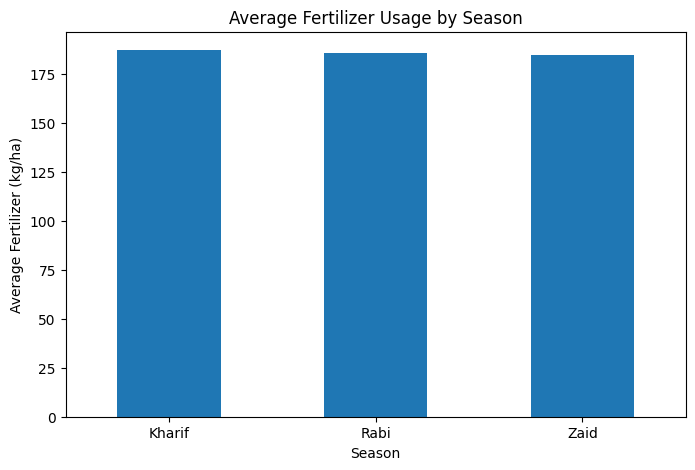

In [177]:
fertilizer_by_season.plot(kind='bar', figsize=(8,5))

plt.title('Average Fertilizer Usage by Season')
plt.xlabel('Season')
plt.ylabel('Average Fertilizer (kg/ha)')
plt.xticks(rotation=0)
plt.show()

In [178]:
water_by_season = df.groupby('Season')['Water_Used_m3'].mean()
print(water_by_season)

Season
Kharif    6102.201237
Rabi      5846.987093
Zaid      6419.893939
Name: Water_Used_m3, dtype: float64


Insight: Water Usage Across Seasons

The average water usage is highest in Zaid at approximately 6419.89 m³, followed by Kharif at 6102.20 m³ and Rabi at 5846.99 m³.

This indicates that water usage varies across seasons in this dataset, with Zaid showing the highest average water requirement.

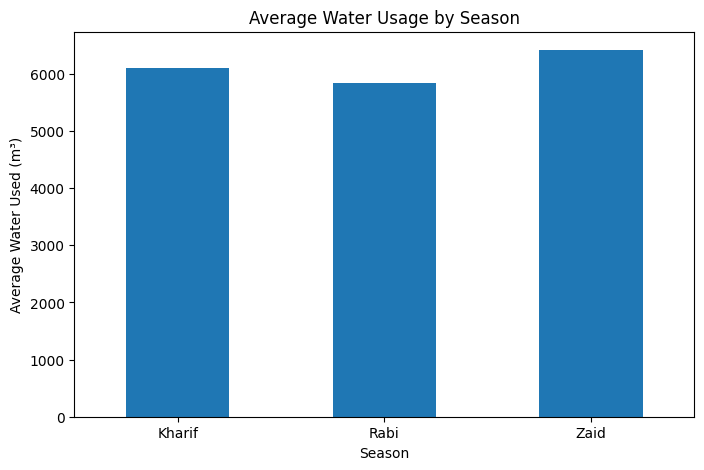

In [179]:
water_by_season.plot(kind='bar', figsize=(8,5))

plt.title('Average Water Usage by Season')
plt.xlabel('Season')
plt.ylabel('Average Water Used (m³)')
plt.xticks(rotation=0)
plt.show()

In [180]:
water_efficiency_yield_corr = df['Water_Efficiency_t_per_1000m3'].corr(
    df['Yield_Tonnes_Ha']
)

print("Correlation between Water Efficiency and Yield:",
      water_efficiency_yield_corr)

Correlation between Water Efficiency and Yield: 0.9125675009144065


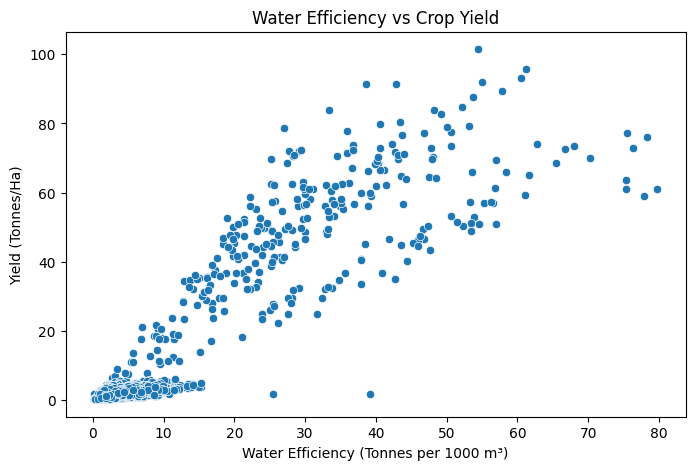

In [181]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Water_Efficiency_t_per_1000m3',
    y='Yield_Tonnes_Ha'
)

plt.title('Water Efficiency vs Crop Yield')
plt.xlabel('Water Efficiency (Tonnes per 1000 m³)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [182]:
economic_by_season = df.groupby('Season')[[
    'Revenue_INR',
    'Total_Cost_INR',
    'Profit_INR'
]].mean()

economic_by_season

,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,710719.055649,531804.408094,178914.647555
Rabi,601526.048556,513836.578365,87689.470191
Zaid,519171.904040,543976.728956,-24804.824916


Insight: Economic Performance Across Seasons

Kharif shows the highest average revenue and average profit in this dataset, with an average revenue of approximately ₹710,719 and an average profit of ₹178,915.

Rabi has an average revenue of approximately ₹601,526 and an average profit of ₹87,689.

Zaid has the lowest average revenue of approximately ₹519,172 and the highest average cost of approximately ₹543,977. As a result, Zaid shows a negative average profit of approximately ₹24,805.

Overall, Kharif shows the strongest average economic performance, while Zaid shows the weakest economic performance in this dataset.

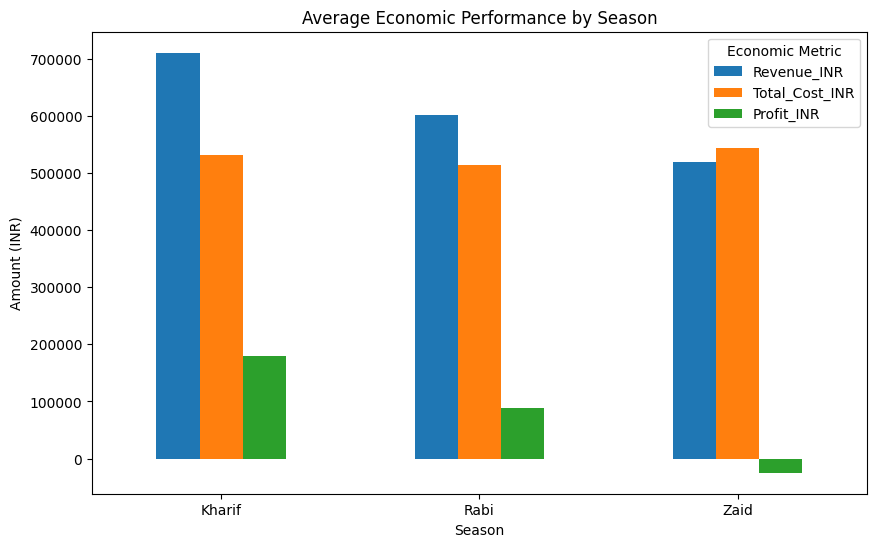

In [183]:
economic_by_season.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Average Economic Performance by Season')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=0)
plt.legend(title='Economic Metric')
plt.show()

In [184]:
profit_by_crop = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)

print(profit_by_crop)

Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Maize        -83978.326679
Rice        -102213.504348
Wheat       -123398.337134
Name: Profit_INR, dtype: float64


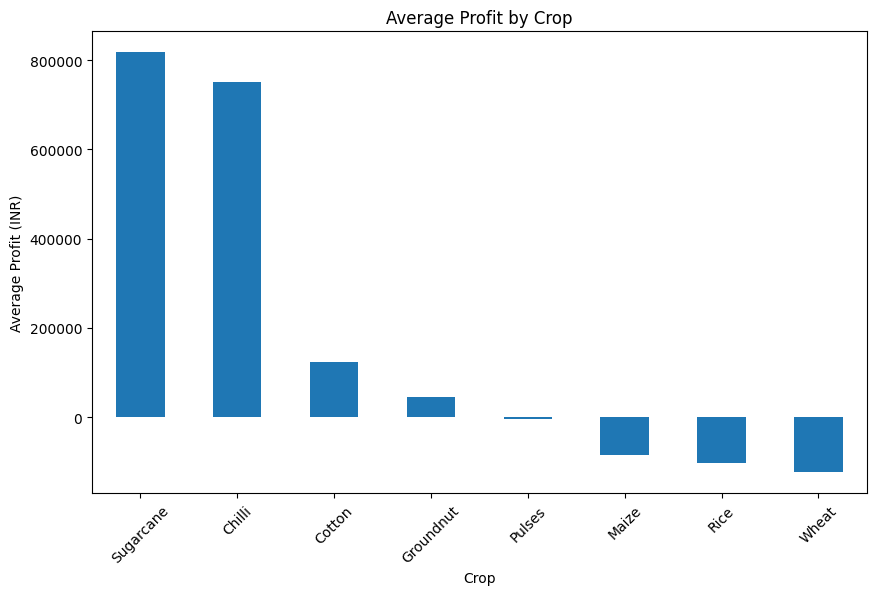

In [185]:
profit_by_crop.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.show()

In [186]:
profit_by_state = df.groupby('State')['Profit_INR'].mean().sort_values(ascending=False)

print(profit_by_state)

State
Punjab            136025.636364
Maharashtra       135428.855469
Karnataka         119422.335378
Tamil Nadu        117744.748454
Gujarat           117568.235656
Telangana         108829.616279
Madhya Pradesh     86840.756539
Andhra Pradesh     73453.527410
Name: Profit_INR, dtype: float64


Insight: Average Profit by State

Punjab has the highest average profit at approximately ₹136,026, followed closely by Maharashtra at approximately ₹135,429.

Karnataka, Tamil Nadu, Gujarat, and Telangana also show positive average profits.

Madhya Pradesh has a lower average profit of approximately ₹86,841, while Andhra Pradesh has the lowest average profit at approximately ₹73,454.

Overall, the results show differences in average profitability across states in this dataset.

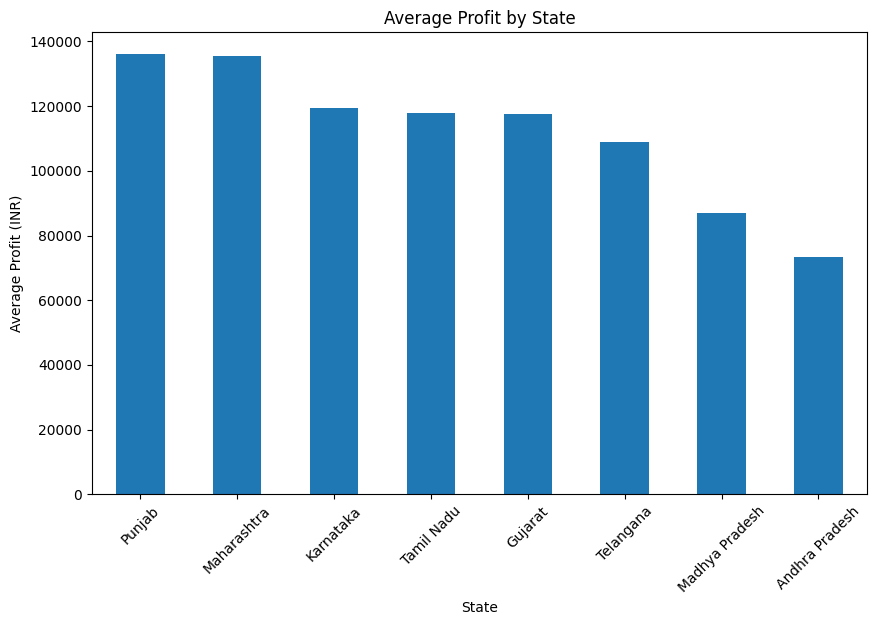

In [187]:
profit_by_state.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Average Profit by State')
plt.xlabel('State')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.show()

In [188]:
state_season_profit = df.groupby(
    ['State', 'Season']
)['Profit_INR'].mean().unstack()

state_season_profit

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.520833,26315.710784,-84084.870588
Gujarat,217051.330317,82846.195000,-106929.611940
Karnataka,201226.205742,70952.611650,23310.905405
Madhya Pradesh,134242.398230,61576.264423,209.698413
Maharashtra,168801.049550,159581.504587,-40597.597222
Punjab,133779.099548,169294.521505,62109.688312
Tamil Nadu,211303.956311,70456.860577,-15175.197183
Telangana,199668.380342,62824.604061,-34620.776471


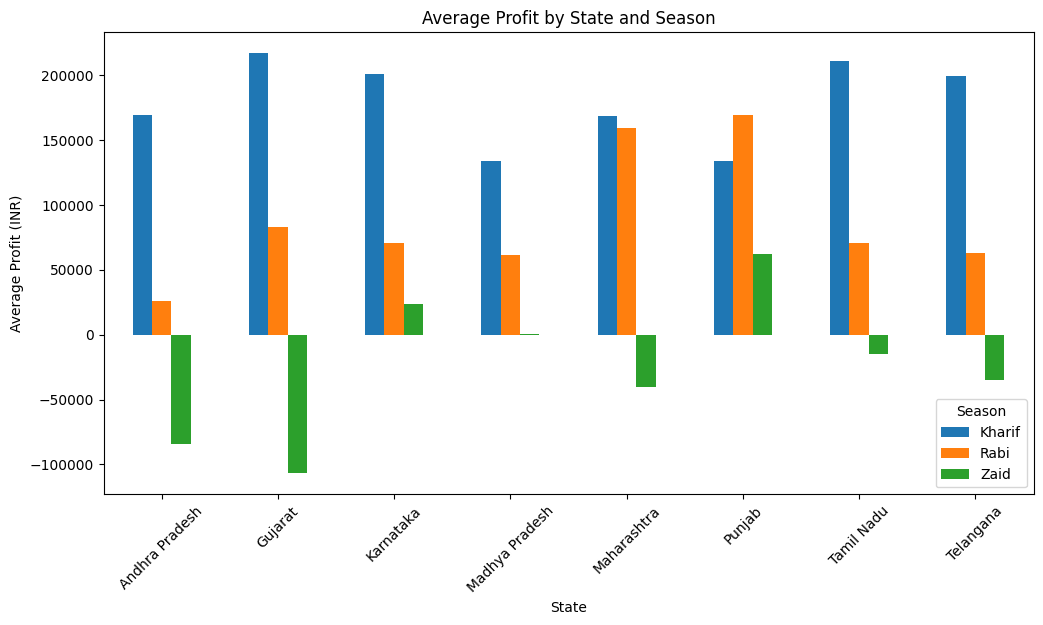

In [189]:
state_season_profit.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Average Profit by State and Season')
plt.xlabel('State')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.show()

In [190]:
pesticide_yield_corr = df['Pesticide_Litre_ha'].corr(
    df['Yield_Tonnes_Ha']
)

print("Correlation between Pesticide Usage and Yield:",
      pesticide_yield_corr)

Correlation between Pesticide Usage and Yield: -0.007779075725186455


Insight: Pesticide Usage vs Yield

The correlation between pesticide usage and crop yield is approximately -0.008, indicating an extremely weak negative linear relationship.

This suggests that pesticide usage alone does not show a meaningful linear relationship with crop yield in this dataset. Other factors may also influence crop yield.

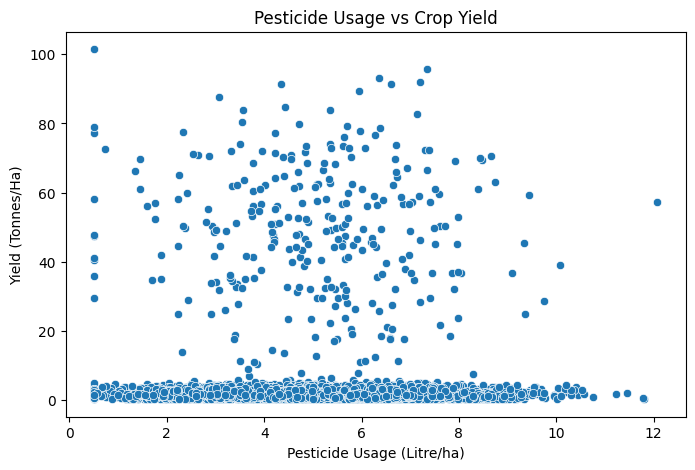

In [191]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Pesticide_Litre_ha',
    y='Yield_Tonnes_Ha'
)

plt.title('Pesticide Usage vs Crop Yield')
plt.xlabel('Pesticide Usage (Litre/ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

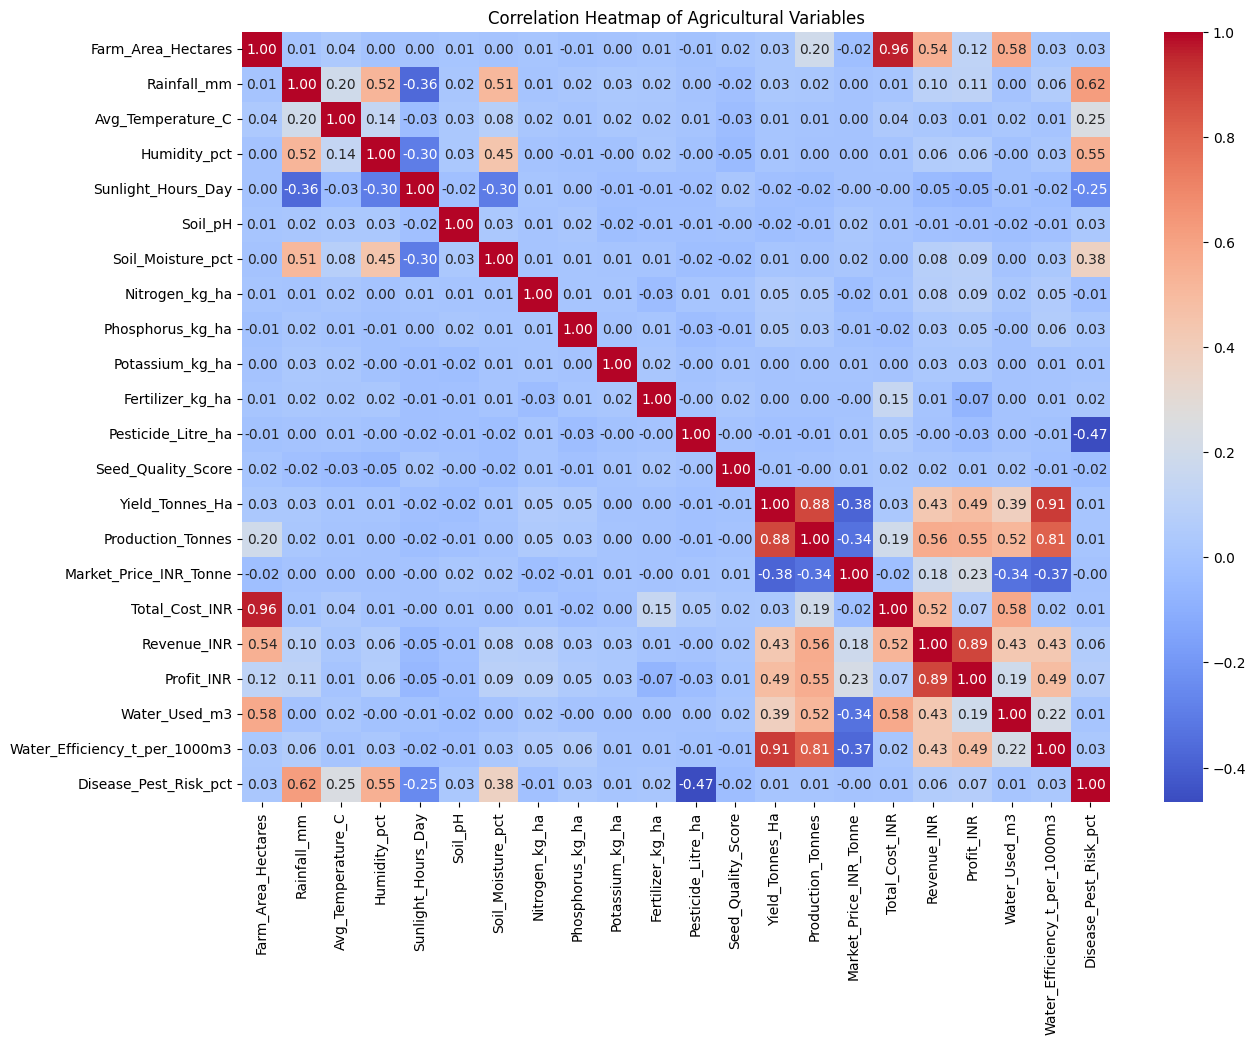

In [192]:
plt.figure(figsize=(14,10))

correlation_matrix = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Agricultural Variables')
plt.show()

In [193]:
negative_profit_crops = profit_by_crop[profit_by_crop < 0]

negative_profit_crops

,Profit_INR
Crop,
Pulses,-4238.052419
Maize,-83978.326679
Rice,-102213.504348
Wheat,-123398.337134


Insight: Crops with Negative Average Profit

The analysis shows that four crops have negative average profit in this dataset: Pulses, Maize, Rice, and Wheat.

Pulses show a small average loss of approximately ₹4,238, while Maize, Rice, and Wheat show larger average losses.

Wheat has the lowest average profit at approximately -₹123,398, followed by Rice at approximately -₹102,214 and Maize at approximately -₹83,978.

This indicates that these crops have weaker average economic performance in the dataset and may require further investigation of their costs, revenue, resource usage, and seasonal performance.

In [194]:
crop_season_profit = df.groupby(
    ['Season', 'Crop']
)['Profit_INR'].mean().unstack()

crop_season_profit

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,954380.421622,216999.548837,108265.440415,-39332.670940,43338.895928,-64903.404459,1.000791e+06,-105871.869863
Rabi,638572.496933,107343.587065,10416.542373,-89133.403433,-14309.136150,-98427.868613,7.316129e+05,-119954.565401
Zaid,448659.093750,-53925.336957,-68872.500000,-194049.166667,-139227.806452,-227239.343137,5.836358e+05,-193208.952941


In [195]:
state_season_profit.stack().sort_values(ascending=False).head(5)

,,0
State,Season,
Gujarat,Kharif,217051.330317
Tamil Nadu,Kharif,211303.956311
Karnataka,Kharif,201226.205742
Telangana,Kharif,199668.380342
Andhra Pradesh,Kharif,169315.520833


In [196]:
state_season_profit.stack().sort_values(ascending=True).head(5)


,,0
State,Season,
Gujarat,Zaid,-106929.611940
Andhra Pradesh,Zaid,-84084.870588
Maharashtra,Zaid,-40597.597222
Telangana,Zaid,-34620.776471
Tamil Nadu,Zaid,-15175.197183


In [197]:
df[['Farm_ID', 'State', 'Crop', 'Season', 'Yield_Tonnes_Ha']].sort_values(
    by='Yield_Tonnes_Ha',
    ascending=False
).head(10)

,Farm_ID,State,Crop,Season,Yield_Tonnes_Ha
1715,SF11716,Gujarat,Sugarcane,Kharif,101.44
3423,SF13424,Andhra Pradesh,Sugarcane,Kharif,95.79
3525,SF13526,Andhra Pradesh,Sugarcane,Rabi,93.13
1464,SF11465,Gujarat,Sugarcane,Kharif,91.98
3523,SF13524,Karnataka,Sugarcane,Kharif,91.46
2782,SF12783,Gujarat,Sugarcane,Rabi,91.32
644,SF10645,Andhra Pradesh,Sugarcane,Kharif,89.34
2847,SF12848,Telangana,Sugarcane,Kharif,87.76
357,SF10358,Punjab,Sugarcane,Rabi,84.75
1178,SF11179,Karnataka,Sugarcane,Kharif,83.79


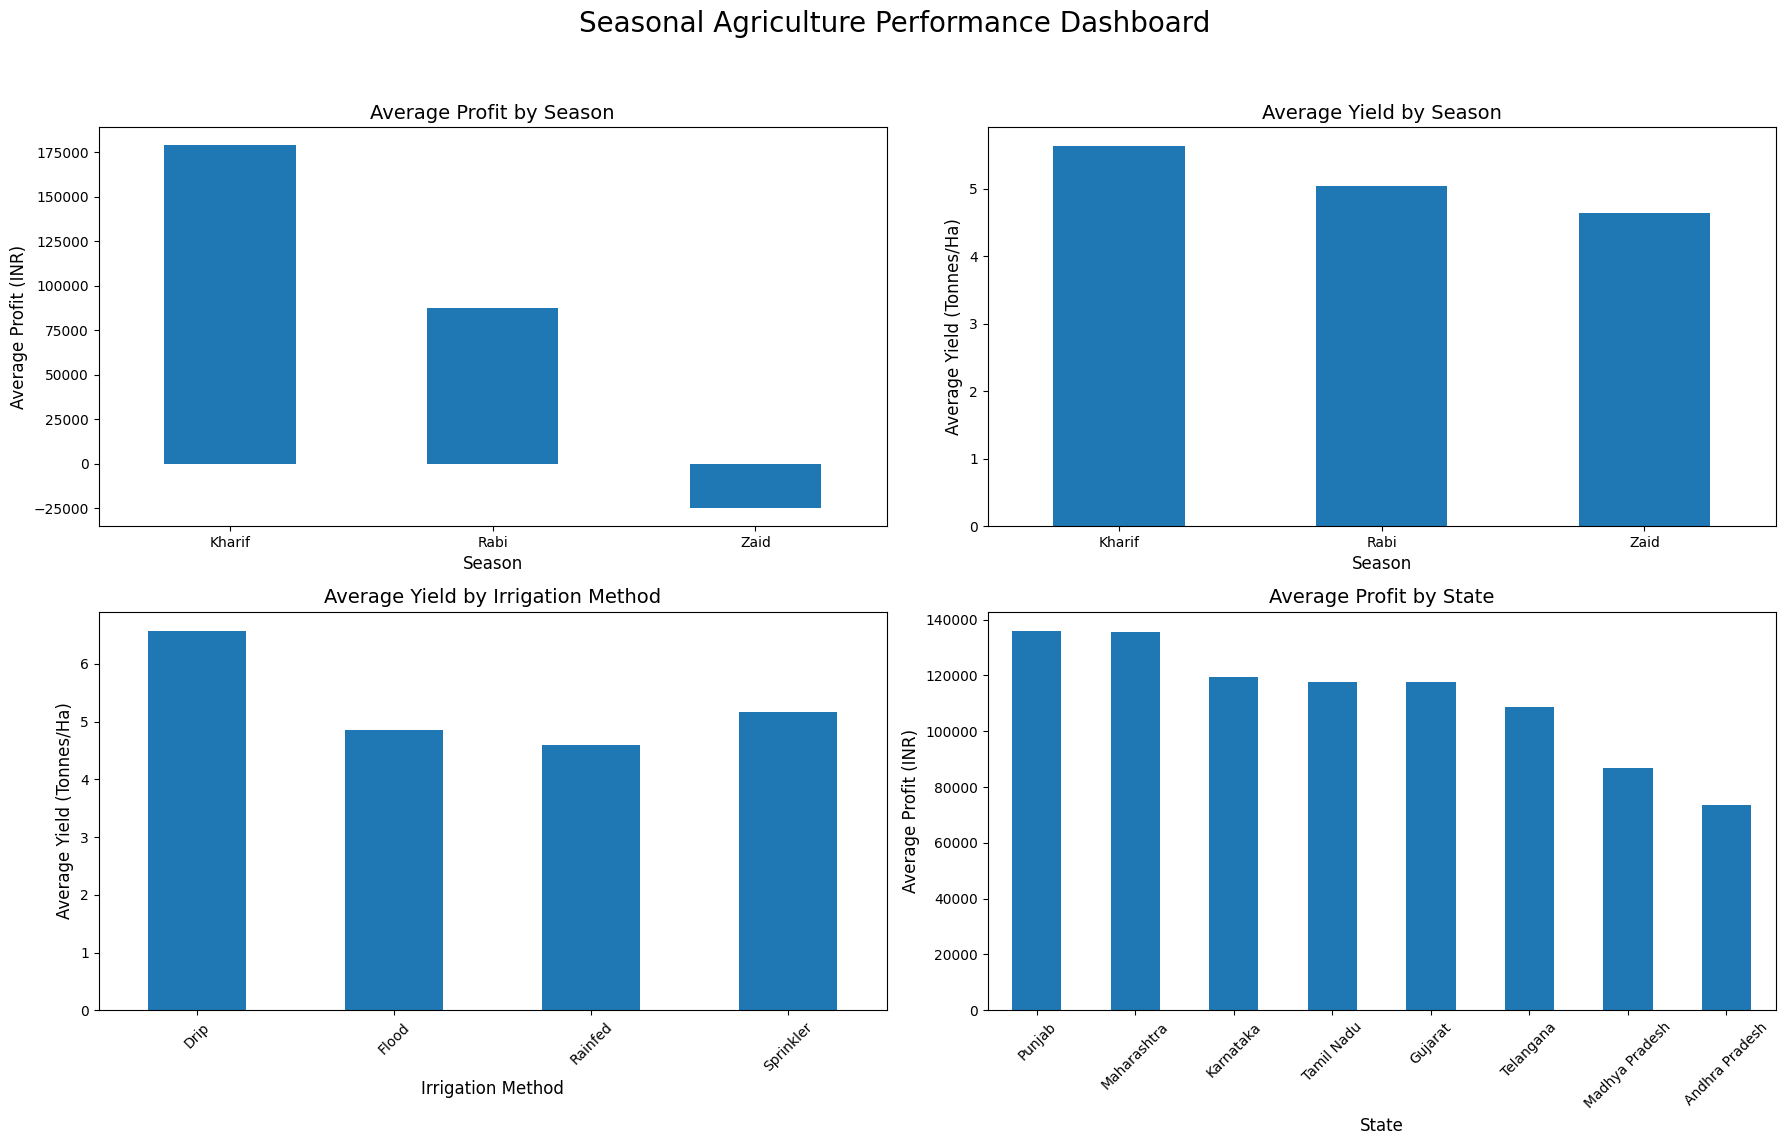

In [198]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle('Seasonal Agriculture Performance Dashboard', fontsize=20)

# Plot 1: Average Profit by Season
season_profit = df.groupby('Season')['Profit_INR'].mean()

season_profit.plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('Average Profit by Season', fontsize=14)
axes[0, 0].set_xlabel('Season', fontsize=12)
axes[0, 0].set_ylabel('Average Profit (INR)', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=0)


# Plot 2: Average Yield by Season
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

season_yield.plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Average Yield by Season', fontsize=14)
axes[0, 1].set_xlabel('Season', fontsize=12)
axes[0, 1].set_ylabel('Average Yield (Tonnes/Ha)', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=0)


# Plot 3: Average Yield by Irrigation Method
irrigation_yield = df.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].mean()

irrigation_yield.plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Average Yield by Irrigation Method', fontsize=14)
axes[1, 0].set_xlabel('Irrigation Method', fontsize=12)
axes[1, 0].set_ylabel('Average Yield (Tonnes/Ha)', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)


# Plot 4: Average Profit by State
state_profit = df.groupby('State')['Profit_INR'].mean().sort_values(ascending=False)

state_profit.plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Average Profit by State', fontsize=14)
axes[1, 1].set_xlabel('State', fontsize=12)
axes[1, 1].set_ylabel('Average Profit (INR)', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Overall Interpretation

The analysis shows that agricultural performance varies across seasons, crops, regions, resource usage and economic conditions.

In the given dataset, Kharif season shows the highest average yield, production, revenue and profit, while Zaid season shows comparatively lower performance and negative average profit.

Crop-wise analysis shows that Sugarcane has the highest average yield and profit across seasons, while some crops show lower or negative profitability.

Environmental variables such as rainfall, temperature, soil moisture, humidity and soil pH show very weak relationships with yield in this dataset. However, water efficiency shows a strong positive relationship with yield.

Resource and farming practice analysis indicates differences in yield across irrigation methods, with Drip irrigation showing the highest average yield in the dataset.

Regional analysis also shows differences in profitability across states and seasons. Kharif generally performs better economically, while Zaid contains several lower-profit combinations.

Overall, the analysis identifies meaningful seasonal patterns, differences and relationships that can support evidence-based agricultural planning.

## Recommendations

1. Agricultural planning should consider seasonal differences in yield, production and profitability.

2. Crops with better profitability and performance should be evaluated for suitable seasonal cultivation.

3. Resource usage should be monitored across seasons, especially water usage, to improve resource efficiency.

4. Water-efficient farming practices can be considered because water efficiency shows a strong positive relationship with yield in the dataset.

5. Regions and crop-season combinations with lower profitability should be investigated further to identify possible factors affecting performance.

6. Seasonal environmental and farming conditions should be monitored to support better agricultural planning.

7. Data analysis should be regularly used to compare seasonal performance and identify unusual patterns.

## Conclusion

The Seasonal Agriculture Performance Analysis provides useful insights into agricultural performance across different seasons, crops and regions.

The analysis shows that Kharif season performs better in terms of average yield, production, revenue and profit, while Zaid season shows comparatively lower performance and negative average profit.

Crop-wise analysis indicates that Sugarcane and Chilli show strong performance and profitability, while some crops have lower or negative profitability.

The analysis also highlights differences in irrigation methods, water usage and water efficiency. Water efficiency shows a strong positive relationship with yield in the dataset.

Regional and seasonal comparisons reveal variations in agricultural profitability across states and crop-season combinations.

Overall, the analysis helps identify important patterns, relationships and variations that can support better agricultural planning and resource management.